In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

In [2]:
base_path = "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset"

In [3]:
label_map = {
    "COVID": 0,
    "Normal": 1,
    "Lung_Opacity": 2,
    "Viral Pneumonia": 3
}

In [4]:
image_paths = []
labels = []

for class_name in label_map:

    folder = os.path.join(
        base_path,
        class_name,
        "images"
    )

    for image_name in os.listdir(folder):

        image_path = os.path.join(
            folder,
            image_name
        )

        image_paths.append(image_path)

        labels.append(
            label_map[class_name]
        )

print("Total Images :", len(image_paths))
print("Total Labels :", len(labels))

Total Images : 21165
Total Labels : 21165


In [5]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

print("Training Images :", len(train_paths))
print("Validation Images :", len(val_paths))
print("Testing Images :", len(test_paths))

Training Images : 14815
Validation Images : 3175
Testing Images : 3175


In [6]:
class ChestXrayDataset(Dataset):

    def __init__(self, image_paths, labels):
        self.image_paths = image_paths
        self.labels = labels

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        # Read image in grayscale
        image = cv2.imread(
            self.image_paths[idx],
            cv2.IMREAD_GRAYSCALE
        )

        # Resize image
        image = cv2.resize(image, (224, 224))

        # Normalize pixel values (0-255 → 0-1)
        image = image.astype(np.float32) / 255.0

        # Convert to PyTorch tensor
        image = torch.tensor(image)

        # Add channel dimension
        image = image.unsqueeze(0)

        # Convert 1 channel → 3 channels
        image = image.repeat(3, 1, 1)

        # Label
        label = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return image, label

In [7]:
train_dataset = ChestXrayDataset(
    train_paths,
    train_labels
)

val_dataset = ChestXrayDataset(
    val_paths,
    val_labels
)

test_dataset = ChestXrayDataset(
    test_paths,
    test_labels
)

In [8]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [9]:
images, labels = next(iter(train_loader))

print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)

Image Batch Shape : torch.Size([32, 3, 224, 224])
Label Batch Shape : torch.Size([32])


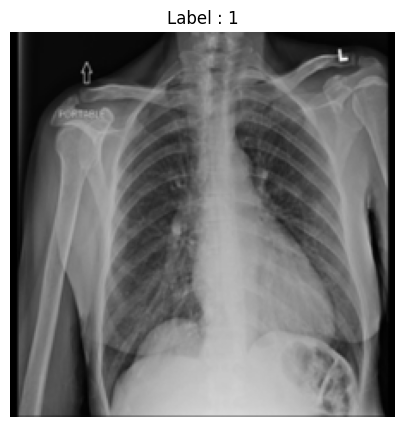

In [10]:
plt.figure(figsize=(5,5))

plt.imshow(
    images[0].permute(1,2,0),
    cmap="gray"
)

plt.title(f"Label : {labels[0].item()}")

plt.axis("off")

plt.show()

In [11]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

print(images.shape)
print(labels.shape)

14815
3175
3175
torch.Size([32, 3, 224, 224])
torch.Size([32])


In [12]:
model = models.mobilenet_v3_large(weights="DEFAULT")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 135MB/s] 


In [13]:
print(model)

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bi

In [14]:
model.classifier[3] = nn.Linear(
    in_features=1280,
    out_features=4
)

In [15]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device:", device)

model = model.to(device)

Using Device: cuda


In [16]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss Function:", criterion)
print("Optimizer:", optimizer)

Loss Function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [17]:
print(model)

print("\nDevice:", device)

dummy = torch.randn(1, 3, 224, 224).to(device)

output = model(dummy)

print("\nOutput Shape:", output.shape)

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bi

In [18]:
num_epochs = 20

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_accuracy = 0

In [19]:
for epoch in range(num_epochs):

    # -------------------------
    # Training
    # -------------------------

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)

    train_accuracy = 100 * correct / total

    train_losses.append(train_loss)

    train_accuracies.append(train_accuracy)

    # -------------------------
    # Validation
    # -------------------------

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(val_loader)

    val_accuracy = 100 * correct / total

    val_losses.append(val_loss)

    val_accuracies.append(val_accuracy)

    print(f"\nEpoch {epoch+1}/{num_epochs}")

    print(f"Training Loss : {train_loss:.4f}")

    print(f"Training Accuracy : {train_accuracy:.2f}%")

    print(f"Validation Loss : {val_loss:.4f}")

    print(f"Validation Accuracy : {val_accuracy:.2f}%")

    # -------------------------
    # Save Best Model
    # -------------------------

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            "best_mobilenetv3.pth"
        )

        print("✅ Best Model Saved")

100%|██████████| 463/463 [03:26<00:00,  2.25it/s]



Epoch 1/20
Training Loss : 0.2793
Training Accuracy : 90.12%
Validation Loss : 0.3573
Validation Accuracy : 87.37%
✅ Best Model Saved


100%|██████████| 463/463 [01:41<00:00,  4.58it/s]



Epoch 2/20
Training Loss : 0.1715
Training Accuracy : 94.13%
Validation Loss : 0.3775
Validation Accuracy : 88.16%
✅ Best Model Saved


100%|██████████| 463/463 [01:41<00:00,  4.58it/s]


...


Epoch 18/20
Training Loss : 0.0380
Training Accuracy : 98.70%
Validation Loss : 0.3968
Validation Accuracy : 93.54%


100%|██████████| 463/463 [01:45<00:00,  4.41it/s]



Epoch 19/20
Training Loss : 0.0294
Training Accuracy : 99.03%
Validation Loss : 0.3677
Validation Accuracy : 92.13%


100%|██████████| 463/463 [01:46<00:00,  4.33it/s]



Epoch 20/20
Training Loss : 0.0305
Training Accuracy : 98.91%
Validation Loss : 0.5631
Validation Accuracy : 92.79%


In [20]:
print("Training Complete!")

print(f"Best Validation Accuracy: {best_val_accuracy:.2f}%")

Training Complete!
Best Validation Accuracy: 93.89%


In [21]:
import os

print(os.listdir())

['best_mobilenetv3.pth', '.virtual_documents']


In [22]:
model.load_state_dict(torch.load("best_mobilenetv3.pth"))

model.eval()

print("Best Model Loaded Successfully!")

Best Model Loaded Successfully!


In [23]:
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Accuracy : {test_accuracy:.2f}%")

Test Accuracy : 93.42%


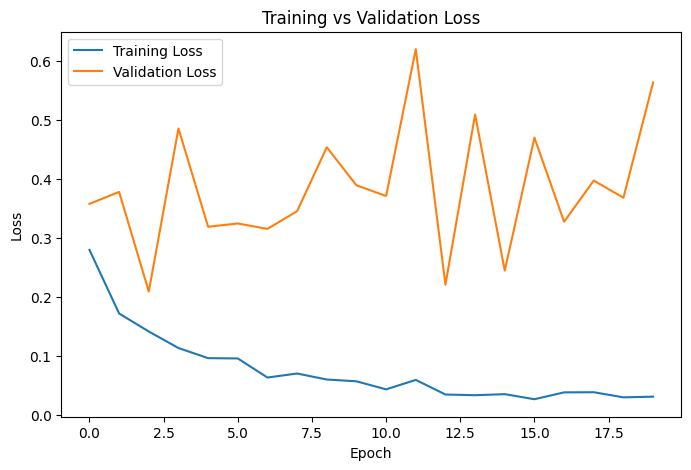

In [24]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

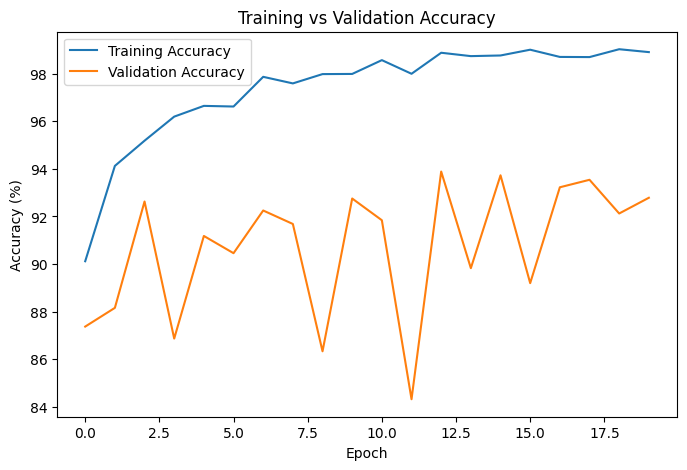

In [25]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

In [26]:
print("="*40)
print("Baseline Training Completed")
print("="*40)

print(f"Best Validation Accuracy : {best_val_accuracy:.2f}%")
print(f"Test Accuracy : {test_accuracy:.2f}%")

print("\nModel Saved As : best_mobilenetv3.pth")

Baseline Training Completed
Best Validation Accuracy : 93.89%
Test Accuracy : 93.42%

Model Saved As : best_mobilenetv3.pth
